<a href="https://colab.research.google.com/github/Erjg1012/Procesamiento-de-Lenguaje-Natural-PLN-/blob/main/Analisis_de_Personalidad_en_Canciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Personalidad

https://www.kaggle.com/datasets/deepshah16/song-lyrics-dataset

## Imports

In [ ]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 8.6 MB/s eta 0:00:00


In [ ]:
import os
import re
import nltk
import contractions

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA



## Directorios

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cargamos los diferentes archivos
csv_folder = '/content/drive/MyDrive/csv'
csv_files = os.listdir(csv_folder)
csv_files

['BTS.csv',
 'NickiMinaj.csv',
 'CardiB.csv',
 'Beyonce.csv',
 'ColdPlay.csv',
 'Drake.csv',
 'LadyGaga.csv',
 'EdSheeran.csv',
 'PostMalone.csv',
 'JustinBieber.csv',
 'Rihanna.csv',
 'KatyPerry.csv',
 'DuaLipa.csv',
 'SelenaGomez.csv',
 'Eminem.csv',
 'CharliePuth.csv',
 'Maroon5.csv',
 'ArianaGrande.csv',
 'Khalid.csv',
 'BillieEilish.csv',
 'TaylorSwift.csv']

## 1. Carga de Datos

In [ ]:
# Cargamos CSVs en uno
combined_lyrics = []

for file_name in csv_files:
    artist_path = os.path.join(csv_folder, file_name)
    try:
        df = pd.read_csv(artist_path)
        combined_lyrics.append(df)
    except Exception as e:
        print(f"Error al leer {file_name}: {e}")

# Unimos todos los DataFrames
df_lyrics = pd.concat(combined_lyrics, ignore_index=True)

In [ ]:
df_lyrics

,Unnamed: 0,Artist,Title,Album,Year,Date,Lyric
0,0.0,BTS (방탄소년단),Dynamite,BE,2020.0,2020-08-21,jungkook 'cause i i i'm in the stars tonight s...
1,1.0,BTS (방탄소년단),FAKE LOVE,LOVE YOURSELF 轉 ‘Tear’,2018.0,2018-05-18,방탄소년단의 fake love 가사 v jungkook 널 위해서라면 난 슬퍼도...
2,2.0,BTS (방탄소년단),MIC Drop (Steve Aoki Remix),NaN,2017.0,2017-11-24,mic drop steve aoki remix 의해 방탄소년단 가사 jhope ...
3,3.0,BTS (방탄소년단),전하지 못한 진심 (The Truth Untold),LOVE YOURSELF 轉 ‘Tear’,2018.0,2018-05-18,방탄소년단의 전하지 못한 진심 가사 v 외로움이 가득히 피어있는 이 garden...
4,4.0,BTS (방탄소년단),봄날 (Spring Day),You Never Walk Alone,2017.0,2017-02-13,rm 보고 싶다 이렇게 말하니까 더 보고 싶다 너희 사진을 보고 있어도 보고 싶다 ...
...,...,...,...,...,...,...,...
6022,474.0,Taylor Swift,Teardrops on my Guitar (Live from Clear Channe...,Live From Clear Channel Stripped 2008,2008.0,2008-06-28,drew looks at me i fake a smile so he won't se...
6023,475.0,Taylor Swift,Evermore [Forward],NaN,2020.0,2020-12-11,to put it plainly we just couldnt stop writing...
6024,476.0,Taylor Swift,Welcome Back Grunwald,NaN,NaN,NaN,turn wycd on you're on your grunwald back from...
6025,477.0,Taylor Swift,Tolerate it (Polskie Tłumaczenie),NaN,2020.0,2020-12-11,zwrotka siedzę i patrzę jak czytasz z głową p...


Columnas disponibles:

- Artist: nombre del artista (puede tener espacios).

- Title: título de la canción.

- Album: nombre del álbum.

- Date y Year: fecha y año de lanzamiento.

- Lyric: letra de la canción.

- Artist: nombre del archivo de origen.

### 1.1 Exploración

- Actividades:

1. Grafico de barras para observar la distribución de canciones por artista
2. Grafico de barras para observar la longitud promedio de las palabras por artista


Resumen estadístico de la longitud de reseñas:
count    6027.000000
mean      374.342459
std       302.295262
min         1.000000
25%       206.000000
50%       330.000000
75%       482.000000
max      5768.000000
Name: review_length, dtype: float64


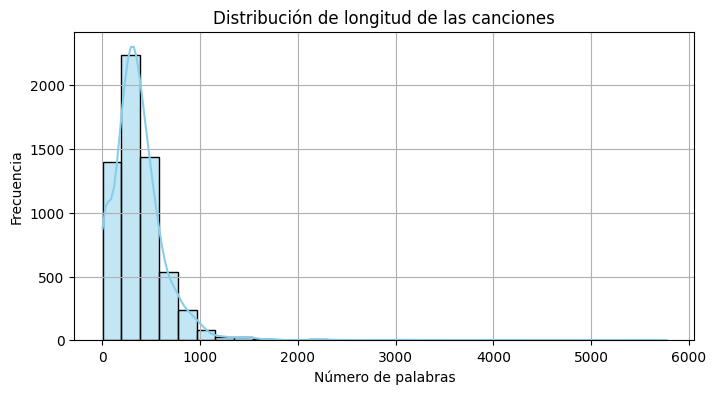

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular longitud de reseñas en palabras
# Convert the 'Lyric' column to string type to handle potential non-string values
df_lyrics['review_length'] = df_lyrics['Lyric'].astype(str).apply(lambda x: len(x.split()))

# Estadísticas descriptivas
print("Resumen estadístico de la longitud de reseñas:")
print(df_lyrics['review_length'].describe())

# Histograma con KDE
plt.figure(figsize=(8, 4))
sns.histplot(df_lyrics['review_length'], bins=30, kde=True, color='skyblue')
plt.title("Distribución de longitud de las canciones")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

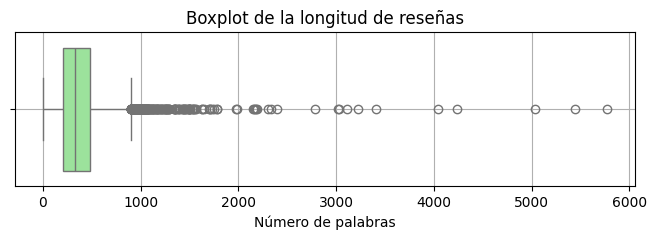

In [ ]:
# Boxplot de longitud total
plt.figure(figsize=(8, 2))
sns.boxplot(x=df_lyrics['review_length'], color='lightgreen')
plt.title("Boxplot de la longitud de reseñas")
plt.xlabel("Número de palabras")
plt.grid(True)
plt.show()

se puede observar que las letras de las canciones en su mayoría se distribuyen de 0 a 900 palabras, teniendo una con mas de 5500, pero estas se considera como outlier como las que pasan de 900 palabras.

### 1.2 Filtramos por artista

- Actividades:

1. Del dataset escoger uno de los artistis para hacer analisis de personalidad. Pueden utilizar la columna lyric o title, o ambas para mas información sobre personalidad.

In [ ]:
df_lyrics[df_lyrics['Artist'] == 'Eminem'][['Lyric', 'Title']]

,Lyric,Title
4238,look i was gonna go easy on you not to hurt yo...,Rap God
4239,you sound like a bitch bitch shut the fuck up ...,Killshot
4240,ugh you're a monster eminem i can swallow a ...,Godzilla
4241,look if you had one shot or one opportunity to...,Lose Yourself
4242,rihanna i'm friends with the monster that's un...,The Monster
...,...,...
4754,may i have your attention please may i have yo...,It’s the real slim shady
4755,lyrics for this song have yet to be released p...,Kill Em’ All
4756,you couldn't impress me if you were elvis pres...,Holy fucking shit..... *Punches drywall*
4757,ئینتڕۆ ئێمینێم هەڵیبێنم ئەمە چیە ها وابزانم ڕو...,Premonition (Intro) (Kurdish Subtitle)


In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize




In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

### 1.3 Normalización de los Datos

- Su proceso  de normalización podría incluir:

    - Pasar todo a minúsculas
    - Eliminar signos de puntuación y caracteres especiales
    - Eliminar números (opcional)
    - Tokenizar (dividir en palabras)
    - Eliminar stopwords (palabras comunes sin valor informativo, como “the”, “and”, “en”, “yo”, etc.)
    - POS Tagging
    - Lematizar o stemming (reducir palabras a su forma base; opcional pero útil)

In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    text = re.sub(r"\d+", "", text)

    custom_words = {"yeah", "oh", "ooh", "na", "wa"}

    tokens = word_tokenize(text, language="english")

    stop_words = set(stopwords.words("english")).union(custom_words)

    tokens = [word for word in tokens if word not in stop_words]

    return tokens


In [ ]:
df_lyrics["cleaned_title"] = df_lyrics["Title"].apply(clean_text)


In [ ]:
df_lyrics["cleaned_lyric"] = df_lyrics["Lyric"].apply(clean_text)


In [ ]:
df_lyrics[df_lyrics['Artist'] == 'Eminem'][['cleaned_lyric', 'cleaned_title']]

,cleaned_lyric,cleaned_title
4238,"[look, gon, go, easy, hurt, feelings, im, goin...","[rap, god]"
4239,"[sound, like, bitch, bitch, shut, fuck, fans, ...",[killshot]
4240,"[ugh, youre, monster, eminem, swallow, bottle,...",[godzilla]
4241,"[look, one, shot, one, opportunity, seize, eve...",[lose]
4242,"[rihanna, im, friends, monster, thats, bed, ge...",[monster]
...,...,...
4754,"[may, attention, please, may, attention, pleas...","[’, real, slim, shady]"
4755,"[lyrics, song, yet, released, please, check, b...","[kill, em, ’]"
4756,"[couldnt, impress, elvis, presley, drinkin, pe...","[holy, fucking, shit, punches, drywall]"
4757,"[ئینتڕۆ, ئێمینێم, هەڵیبێنم, ئەمە, چیە, ها, واب...","[premonition, intro, kurdish, subtitle]"


## 2. Vectorización de los Datos

In [ ]:

vectorizer = TfidfVectorizer(
    lowercase=False,          # Ya convertido a minúsculas en preprocesamiento
    stop_words=None,           # Stopwords ya eliminados en limpieza
    max_features=1000,        # Tamaño del vocabulario (explicación abajo)
    ngram_range=(1, 2),        # Unigramas y bigramas (explicación abajo)
    max_df=0.85,               # Filtrar términos demasiado comunes
    min_df=5                   # Filtrar términos muy raros
)
df_lyrics["cleaned_title_str"] = df_lyrics["cleaned_title"].apply(lambda tokens: " ".join(tokens))
df_lyrics["cleaned_lyric_str"] = df_lyrics["cleaned_lyric"].apply(lambda tokens: " ".join(tokens))
title_vectors = vectorizer.fit_transform(df_lyrics["cleaned_title_str"])
lyric_vectors = vectorizer.fit_transform(df_lyrics["cleaned_lyric_str"])


In [ ]:
df_lyrics["cleaned_title_str"]

,cleaned_title_str
0,dynamite
1,fake love
2,mic drop steve aoki remix
3,전하지 못한 진심 truth untold
4,봄날 spring day
...,...
6022,teardrops guitar live clear channel stripped
6023,evermore forward
6024,welcome back grunwald
6025,tolerate polskie tłumaczenie


In [ ]:
df_lyrics["cleaned_lyric_str"]

,cleaned_lyric_str
0,jungkook cause im stars tonight watch bring fi...
1,방탄소년단의 fake love 가사 v jungkook 널 위해서라면 난 슬퍼도 기...
2,mic drop steve aoki remix 의해 방탄소년단 가사 jhope 누가...
3,방탄소년단의 전하지 못한 진심 가사 v 외로움이 가득히 피어있는 이 garden 가...
4,rm 보고 싶다 이렇게 말하니까 더 보고 싶다 너희 사진을 보고 있어도 보고 싶다 ...
...,...
6022,drew looks fake smile wont see want im needing...
6023,put plainly couldnt stop writing songs try put...
6024,turn wycd youre grunwald back amazon ah huh hu...
6025,zwrotka siedzę patrzę jak czytasz z głową poch...


###  2.1 Exploración de n gramas mas frecuentes

- Generar un grafico donde se muestren los nombres de los 20 ngramas más comunes

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer


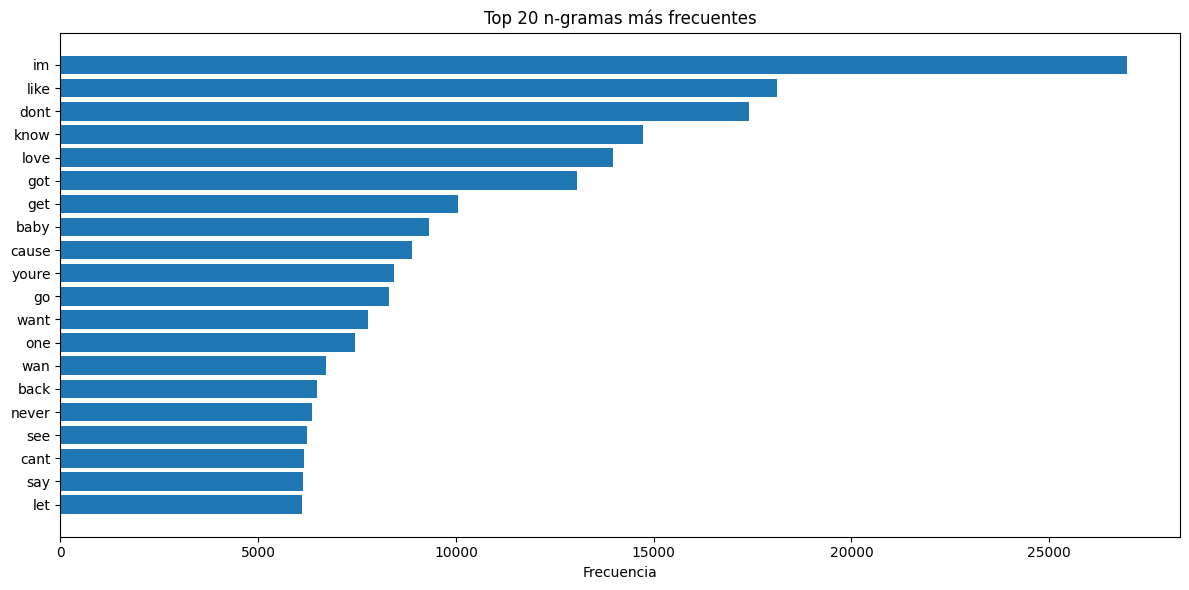

In [ ]:
# Usamos unigramas y bigramas
vectorizer = CountVectorizer(ngram_range=(1,2), max_df=0.85, min_df=5, max_features=1000)
X_counts = vectorizer.fit_transform(df_lyrics["cleaned_lyric_str"])

# Obtener nombres de ngramas y sus frecuencias totales
sums = X_counts.sum(axis=0)
words_freq = [(word, sums[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:20]

# Crear gráfico
ngrams, freqs = zip(*words_freq)
plt.figure(figsize=(12, 6))
plt.barh(ngrams[::-1], freqs[::-1])  # Mostrar de mayor a menor
plt.title("Top 20 n-gramas más frecuentes")
plt.xlabel("Frecuencia")
plt.tight_layout()
plt.show()

### 3. Agrupacion por K-means

- Actividades:

1. Entrenar K-means
2. Visualizacion de los clusters
4. Revisar las palabras más frecuentes por cluster.
5. Interpretar cada cluster en términos de OCEAN. Revisar las palabras más representativas por cluster:

    - Asociar cada grupo con los rasgos del modelo OCEAN según el contenido.
        - Ejemplo: letras con muchas palabras emocionales negativas → Neuroticismo.
        - Letras introspectivas con metáforas → Apertura.
        - Letras de fiesta, interacción social → Extraversión.

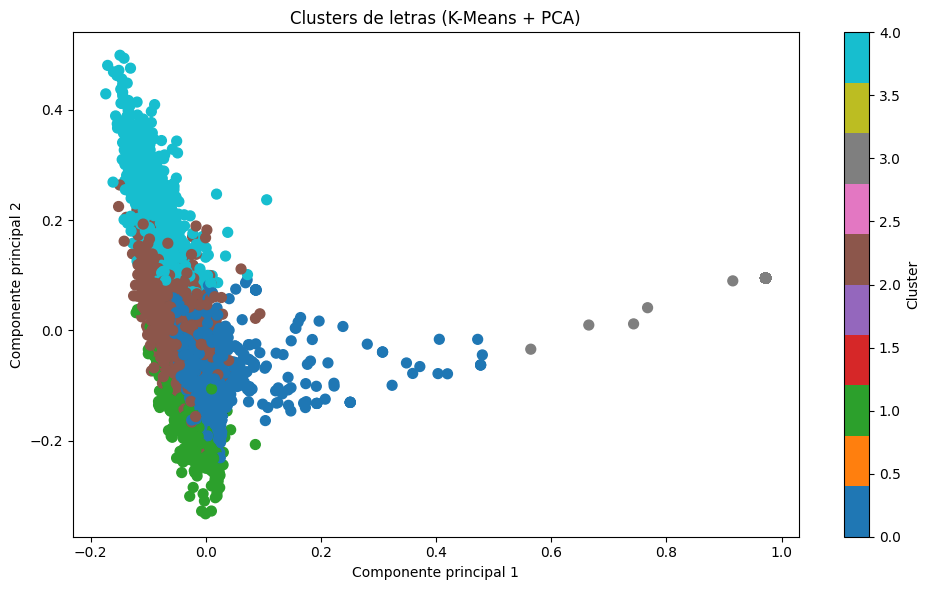

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Aplicar K-means (5 clusters como referencia para OCEAN)
kmeans = KMeans(n_clusters=5, random_state=13)
labels = kmeans.fit_predict(lyric_vectors)

# Visualización con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(lyric_vectors.toarray())

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=50)
plt.title("Clusters de letras (K-Means + PCA)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()


In [ ]:

# Centroides del modelo KMeans (en espacio TF-IDF)
centroids = kmeans.cluster_centers_
terms = vectorizer.get_feature_names_out()

# Palabras más frecuentes por cluster
for i, center in enumerate(centroids):
    top_indices = center.argsort()[::-1][:10]  # Top 10 palabras
    top_words = [terms[idx] for idx in top_indices]
    print(f"\nCluster {i} → Palabras más representativas:")
    print(", ".join(top_words))



Cluster 0 → Palabras más representativas:
im, like, get, got, one, come, love, dont, never, know

Cluster 1 → Palabras más representativas:
love, jungkook, love love, jimin, la la, la, jin, rm, jhope, im

Cluster 2 → Palabras más representativas:
dont, im, know, love, youre, baby, like, wan, got, cause

Cluster 3 → Palabras más representativas:
released, song, song yet, yet released, lyrics song, check back, released please, back song, song released, please check

Cluster 4 → Palabras más representativas:
im, like, got, shit, get, bitch, fuck, dont, aint, know


Análisis de Clústeres de Palabras Representativas con el Esquema OCEAN
Este análisis interpreta las palabras más representativas de cada clúster utilizando el esquema de personalidad OCEAN (Apertura a la Experiencia, Conciencia, Extraversión, Amabilidad y Neuroticismo). Es importante recordar que estas son inferencias especulativas basadas en el lenguaje y no en evaluaciones psicológicas directas.

###Cluster 0
**palabras:** "im, like, get, got, one, come, love, dont, never, know"
Este clúster sugiere un lenguaje cotidiano, informal y centrado en la acción y la experiencia personal.

- Apertura a la Experiencia (O): Moderada. Palabras como "know" y "come" podrían indicar una disposición a nuevas situaciones, pero no un énfasis fuerte en la imaginación.
Conciencia (C): Baja. El vocabulario es más reactivo ("get", "got") y carece de términos que sugieran planificación o estructura.
- Extraversión (E): Moderada. Hay una implicación con el entorno ("im", "one" en acciones) y preferencias ("like"), pero sin el dinamismo social o la alta energía.
Amabilidad (A): Moderada a Baja. "Don't" y "never" pueden indicar negación o frustración, lo que contrasta con la amabilidad, aunque "love" es una excepción.
- Neuroticismo (N): Moderado. "Don't" y "never" sugieren negación, frustración o una perspectiva cautelosa, lo que apunta a cierto nivel de neuroticismo.

###Cluster 1
**Palabras:** "love, jungkook, love love, jimin, la la, la, jin, rm, jhope, im"

Este clúster es altamente específico y emotivo, dominado por la palabra "love" y nombres propios. Claramente relacionado con fanáticos de K-Pop (BTS).

- Apertura a la Experiencia (O): Moderada a Alta. El interés en una cultura musical específica y la expresión emocional ("love love", "la la") sugieren apertura a nuevas experiencias culturales y estéticas.
- Conciencia (C): No detectable. Las palabras no ofrecen información sobre organización o autodisciplina.
- Extraversión (E): Alta. La repetición de "love", exclamaciones y la mención de figuras públicas indican una expresión abierta de entusiasmo y afecto, alineándose con la extraversión.
- Amabilidad (A): Muy Alta. "Love" y la admiración por los miembros de BTS son fuertes indicadores de afecto, aprecio y amabilidad.
- Neuroticismo (N): Baja. No hay palabras que sugieran ansiedad o inestabilidad emocional. El tono es predominantemente positivo y afectuoso.

###Cluster 2
**Palabras**: "dont, im, know, love, youre, baby, like, wan, got, cause"
Similar al Cluster 0 en su informalidad, pero con un enfoque más interpersonal y relacional, incluyendo términos afectivos.

- Apertura a la Experiencia (O): Moderada. "Know" y expresiones de deseo ("wan" - want) pueden indicar curiosidad, pero no una fuerte apertura a la novedad.
- Conciencia (C): Baja. El lenguaje es más espontáneo y menos planificado.
- Extraversión (E): Moderada. La inclusión de "you're" y "baby" sugiere una orientación hacia los demás y las relaciones, aunque sin el dinamismo social del Clúster 1.
- Amabilidad (A): Moderada. "Love" y "baby" son indicadores de afecto, pero "don't" y "cause" podrían introducir elementos de justificación o explicación.
- Neuroticismo (N): Moderado. "Don't" y "know" (en contextos de incertidumbre) pueden señalar ansiedad o frustración.


###Cluster 3
**Palabras:** "released, song, song yet, yet released, lyrics song, check back, released please, back song, song released, please check"
Este clúster es altamente funcional y específico, centrado en la disponibilidad de contenido musical. Refleja una búsqueda de información o un estado de espera.

- Apertura a la Experiencia (O): Baja. El lenguaje es muy concreto y funcional, sin elementos de imaginación o nuevas ideas. Se trata de una expectativa ya definida.
- Conciencia (C): Alta. Palabras como "check back" y "please check" sugieren una orientación a la tarea, la diligencia y la atención a los detalles (la disponibilidad de la canción).
- Extraversión (E): Baja. El lenguaje es impersonal, centrado en la información y la acción de verificar, no en la interacción social.
- Amabilidad (A): Moderada. El uso de "please" indica cortesía.
- Neuroticismo (N): Moderado. La repetición de "yet released" o "check back" puede indicar impaciencia o anticipación ansiosa.


###Cluster 4
**Palabras:** "im, like, got, shit, get, bitch, fuck, dont, aint, know"
Este clúster se caracteriza por un lenguaje informal, coloquial y a menudo vulgar, reflejando una expresión cruda y posiblemente confrontacional.

- Apertura a la Experiencia (O): Baja. El lenguaje es muy centrado en la realidad inmediata, sin elementos de imaginación o aprecio estético. La vulgaridad no suele asociarse con alta apertura.
- Conciencia (C): Muy Baja. Las palabras son impulsivas y no reflejan planificación, orden o autodisciplina. Es un lenguaje reactivo.
- Extraversión (E): Moderada a Alta. El uso de lenguaje fuerte ("shit", "fuck", "bitch") puede ser una forma de autoexpresión o de interacción dominante.
- Amabilidad (A): Muy Baja. El lenguaje explícito y los términos despectivos son claros indicadores de baja amabilidad, sugiriendo hostilidad.
- Neuroticismo (N): Alta. La presencia de lenguaje vulgar y posiblemente agresivo puede ser una manifestación de ira, frustración o inestabilidad emocional.

*nota. a pesar de que se realizo la eliminación manual de palabras, podemos notar que aparecen palabras que no aportan tanto a este análisis, por lo que se podría seguir eliminando palabras a mano, pero no creo que eso sea lo más eficiente.*